# Runtime: < 1min

After you got all the hotspot location:
1. Create a graph considering all the hotspot as a single node, and edges will have distance, time, weight informations.
2. While adding distance in edge you may use geodesic distance initially.
    * Calculate distance using geodesic (great circle distance)
     distance_km = geodesic(coord1, coord2).kilometers
3. Print no of nodes and edges.
4. Then to reduce the number of edges, we will drop edges with a threshold distance(distance > 10 km)
5. Print remaining number of edges after droping with different threshold distance (5,7,10,15 km)
6. After checking the total remaining edge we need to decide which threshold to take finally.

Then we can move into the graphhopper queries to update the geodesic distance with real-road distance.

# Imports

In [1]:
import networkx as nx
import geopandas as gpd
from geopy.distance import geodesic
import pandas as pd
import matplotlib.pyplot as plt
from shapely.geometry import LineString
import os
import json

# Parameters

In [2]:
idx = -1

my_states = ["New Mexico", "Massachusetts", "Ohio", "Texas", "Florida", "Washington", "Illinois", "New Mexico"]
state_name = my_states[idx]


my_cities = ["Albuquerque", "Boston", "Cleveland", "Dallas", "Miami", "Seattle", "Chicago", "Santa Fe"]
city_name = my_cities[idx]

# Setup/Loading Data

In [3]:
# Ensure working directory is repo root (parent of city_data_generation/)
if os.path.basename(os.getcwd()) == "city_data_generation":
    os.chdir("..")

# Define the file paths
data_dir = os.path.join("data_real", city_name.lower().replace(" ", "_"))
hotspot_dir = data_dir + "/hotspot_data.geojson"
census_dir = data_dir + "/census/census_tract_data.geojson"

# Load the hotspot and census data into a geodataframe
hotspot_gdf = gpd.read_file(hotspot_dir)
census_gdf = gpd.read_file(census_dir)

# Extract lon and lat values for every hotspot
coords = []
for point in hotspot_gdf['geometry']:
    # This might need to be inverted to (y,x)
    # This is needed
    coords.append((point.y, point.x))

# Extract GEOIDs
GEOIDs = list(hotspot_gdf['GEOID'])

# Graph Creation and Geodesic Distances

In [4]:
# Make an empty graph
graph = nx.Graph()

# Let the GEOIDs represent the nodes
graph.add_nodes_from(GEOIDs)

# Each edge will consist of a source node, target node, distance, time, weight
edges = []

# Loop through all possible pairs of nodes
for i in range(len(coords)):
    for j in range(i+1, len(coords)):
        from_coord = coords[i]
        to_coord = coords[j]

        from_node = GEOIDs[i]
        to_node = GEOIDs[j]

        # Calculate the geodesic distance between the two nodes
        # For now we can use this distance as the weight as well
        distance_km = geodesic(from_coord, to_coord).kilometers

        # Since we dont have the time values we can approimate
        speed_kmh = 50
        time_hours = distance_km / speed_kmh

        edges.append({
            'from_node': from_node,
            'to_node': to_node,
            'distance_km': distance_km,
            'time_hours': time_hours,
            'weight': distance_km
        })

# Turn the edges into a dataframe
edges_df = pd.DataFrame(edges)

# Add the edges from the df to the graph
for idx, row in edges_df.iterrows():
    graph.add_edge(row['from_node'],
              row['to_node'],
              distance_km=row['distance_km'],
              time_hours=row['time_hours'],
              weight=row['weight'])

# Analysis and Threshold Testing
I think we should check the connectivity of the graph. If we make the threshold too low it may result in having different island graphs in the city. My approach and what I found might be the best solution is to iteratively check what the lowest threshold can be without creating a disconnected graph. Show source?

In [5]:
def check_connectivity(edges_df, GEOIDs, threshold_km, thresholds):
    # Drop edges that have a distance larger than {threshold}
    filtered_edges = edges_df[edges_df['distance_km'] <= threshold_km]
    num_filtered_edges = len(filtered_edges)
    print(f"\n- Threshold: {threshold_km}\nNumber of filtered edges: {num_filtered_edges}")

    # Create a temporary graph
    graph_temp = nx.Graph()
    graph_temp.add_nodes_from(GEOIDs)
    graph_temp.add_edges_from(filtered_edges[['from_node', 'to_node']].values)

    # Check for the number of components
    num_components = nx.number_connected_components(graph_temp)
    print(f"Number of components: {num_components}")

    # update threholds metrics
    num_nodes = graph_temp.number_of_nodes()
    thresholds[f"{threshold_km}"] = {"nodes": num_nodes, "edges": num_filtered_edges, "components": num_components}

    # Check for connectivity
    # Dallas seems to be weird selection becasue of their census tracts that are
    # farther from the main city
    if num_components == 1 or city_name == "Dallas" and num_components == 2:
        print("The graph is connected.")
        return True

    print("The graph is not connected.")
    return False

In [6]:
# Retrieve and display the number of nodes and edges
num_nodes = graph.number_of_nodes()
num_edges = graph.number_of_edges()
num_components = nx.number_connected_components(graph)

# Store threshold stats
thresholds = {}
thresholds["none"] = {"nodes": num_nodes, "edges": num_edges, "components": num_components}

# thresholds: 0,1,2,3,4,5,6,...
# each with a dict as their value: edges, nodes, compponents

print(f"Number of unadjusted nodes: {num_nodes}")
print(f"Number of unadjusted edges: {num_edges}")

# Define the threshold distances (km)
MAX_THRESHOLD = 15
optimal_threshold = 15

# Loop from 15 - 1 thresholds
for i in range(MAX_THRESHOLD, 0, -1):
    if not check_connectivity(edges_df, GEOIDs, i, thresholds):
        optimal_threshold = i + 1
        break

print(f"\nOptimal threshold: {optimal_threshold}")

Number of unadjusted nodes: 30
Number of unadjusted edges: 435

- Threshold: 15
Number of filtered edges: 433
Number of components: 1
The graph is connected.

- Threshold: 14
Number of filtered edges: 430
Number of components: 1
The graph is connected.

- Threshold: 13
Number of filtered edges: 422
Number of components: 1
The graph is connected.

- Threshold: 12
Number of filtered edges: 407
Number of components: 1
The graph is connected.

- Threshold: 11
Number of filtered edges: 390
Number of components: 1
The graph is connected.

- Threshold: 10
Number of filtered edges: 369
Number of components: 1
The graph is connected.

- Threshold: 9
Number of filtered edges: 342
Number of components: 1
The graph is connected.

- Threshold: 8
Number of filtered edges: 318
Number of components: 1
The graph is connected.

- Threshold: 7
Number of filtered edges: 283
Number of components: 1
The graph is connected.

- Threshold: 6
Number of filtered edges: 246
Number of components: 1
The graph is co

# Data Manipulation

In [7]:
# Apply the optimal threshold
optimal_edges_df = edges_df[edges_df['distance_km'] <= optimal_threshold]

optimal_graph = nx.Graph()
optimal_graph.add_nodes_from(GEOIDs)

# Iterate over the df to add edges with attributes
for index, row in optimal_edges_df.iterrows():
    # Convert node IDs to string as a safeguard before adding to graph
    optimal_graph.add_edge(
        str(row['from_node']),
        str(row['to_node']),
        distance_km=row['distance_km'],
        time_hours=row['time_hours'],
        weight=row['weight']
    )

# Merge the edge data with the actual coordinates (geometry) of the nodes
# Helps with visualization
merged_edges = optimal_edges_df.merge(
    hotspot_gdf[['GEOID', 'geometry']].rename(columns={'geometry': 'source_geom'}),
    left_on='from_node',
    right_on='GEOID'
).merge(
    hotspot_gdf[['GEOID', 'geometry']].rename(columns={'geometry': 'target_geom'}),
    left_on='to_node',
    right_on='GEOID',
    suffixes=('_source', '_target')
)

# Create a geoseries of linestring objects from the source/target coordinates
merged_edges['geometry'] = merged_edges.apply(
    lambda row: LineString([row['source_geom'], row['target_geom']]),
    axis=1
)

# We must keep only the desired linestring geometry column for geojson export
merged_edges = merged_edges.drop(columns=['source_geom', 'target_geom'])

# Convert to geodataframe
edges_gdf = gpd.GeoDataFrame(merged_edges, geometry='geometry', crs=hotspot_gdf.crs)

# Prepare a dataframe with coordinates for the CSV output
# First, get a dataframe with GEOID and lat/lon
coords_df = hotspot_gdf[['GEOID', 'geometry']].copy()
# Ensure coordinates are in separate columns
coords_df['lat'] = coords_df['geometry'].apply(lambda p: p.y)
coords_df['lon'] = coords_df['geometry'].apply(lambda p: p.x)
coords_df = coords_df.drop(columns=['geometry'])
coords_df['GEOID'] = coords_df['GEOID'].astype(str)

# Start with the edges data
csv_ready_df = optimal_edges_df.copy()

# Ensure node IDs are strings for merging
csv_ready_df['from_node'] = csv_ready_df['from_node'].astype(str)
csv_ready_df['to_node'] = csv_ready_df['to_node'].astype(str)

# Merge with source node coordinates
csv_ready_df = csv_ready_df.merge(
    coords_df.rename(columns={'lat': 'lat_from', 'lon': 'lon_from'}),
    left_on='from_node',
    right_on='GEOID'
).drop(columns=['GEOID']) # Drop the redundant GEOID column from the merge

# Merge with target node coordinates
csv_ready_df = csv_ready_df.merge(
    coords_df.rename(columns={'lat': 'lat_to', 'lon': 'lon_to'}),
    left_on='to_node',
    right_on='GEOID'
).drop(columns=['GEOID']) # Drop the redundant GEOID column from the merge

# Select and reorder columns to match the desired output
csv_ready_df = csv_ready_df[['from_node', 'to_node', 'distance_km', 'time_hours', 'weight', 'lat_from', 'lon_from', 'lat_to', 'lon_to']]

# Save all the data
# Save geojson (for plotting and final map file)
output_geojson_file = data_dir + '/optimal_edges_lines.geojson'
edges_gdf.to_file(output_geojson_file, driver='GeoJSON')
print(f"Visualization GeoJSON saved: {output_geojson_file}")

# Save CSV (possible input list for GraphHopper queries)
output_csv_file = data_dir + '/template_optimal_edges_list.csv'
csv_ready_df.to_csv(output_csv_file, index=False)
print(f"GraphHopper Input CSV saved: {output_csv_file}")

# Save NetworkX Graph (for graph analysis )
output_graphml_file = data_dir + '/optimal_graph.graphml'
nx.write_graphml(optimal_graph, output_graphml_file)
print(f"NetworkX GraphML saved: {output_graphml_file}")

Visualization GeoJSON saved: data_real/santa_fe/optimal_edges_lines.geojson
GraphHopper Input CSV saved: data_real/santa_fe/template_optimal_edges_list.csv
NetworkX GraphML saved: data_real/santa_fe/optimal_graph.graphml


# Visualizations

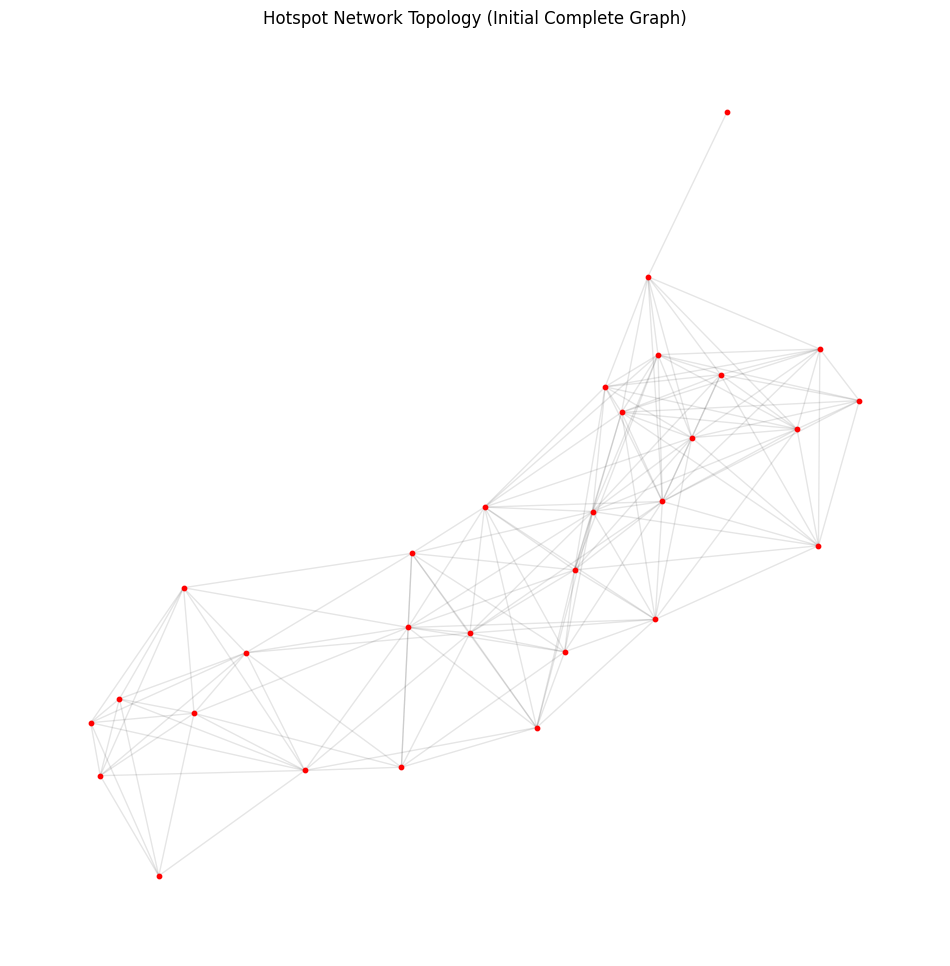

In [8]:
pos = {}
for geoid, geom in zip(hotspot_gdf['GEOID'], hotspot_gdf.geometry):
    pos[geoid] = (geom.x, geom.y)

plt.figure(figsize=(12, 12))

nx.draw_networkx_nodes(optimal_graph, pos, node_size=10, node_color='red')

nx.draw_networkx_edges(optimal_graph, pos, alpha=0.1)

plt.title("Hotspot Network Topology (Initial Complete Graph)")
plt.axis('off') # Hide the axes ticks and labels for a cleaner look
plt.show()
plt.close()

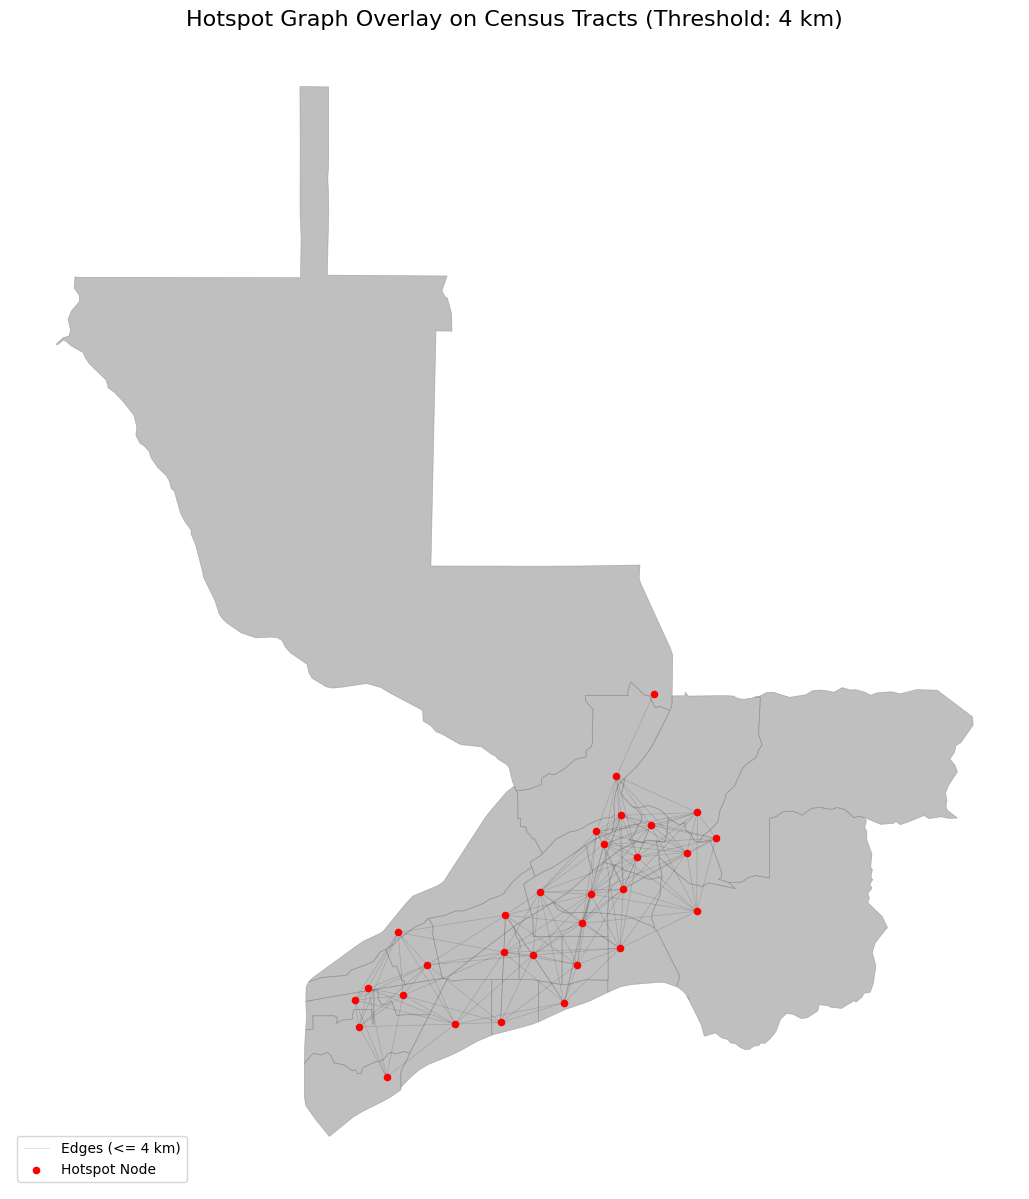

In [9]:
# Create multi layer plot
fig, ax = plt.subplots(1, 1, figsize=(15, 15))

# Base layer: census tract polygons
census_gdf.plot(ax=ax, color='grey', edgecolor='gray', linewidth=0.5, alpha=0.5)

# Middle layer: optimal edges (lines)
# Use low transparency since so many edges
edges_gdf.plot(
    ax=ax,
    color='black',
    linewidth=0.5,
    alpha=0.15,
    label=f"Edges (<= {optimal_threshold} km)"
)

# Top layer: hotspot nodes (points)
hotspot_gdf.plot(
    ax=ax,
    marker='o',
    color='red',
    markersize=20,
    zorder=5,  # Ensure points are drawn on top of lines
    label="Hotspot Node"
)

# Customize the plot
ax.set_title(f"Hotspot Graph Overlay on Census Tracts (Threshold: {optimal_threshold} km)", fontsize=16)
ax.set_axis_off()
ax.legend(loc='lower left')

# Save the image before showing it
os.makedirs(data_dir + "/images", exist_ok=True)
output_filename = data_dir + f'/images/hotspot_graph_overlay_{optimal_threshold}km.png'
plt.savefig(output_filename, bbox_inches='tight', dpi=300)
plt.show()
plt.close()

# Test Data

In [10]:
import pandas as pd
import geopandas as gpd

# Load the saved CSV file
test_csv_file = data_dir + '/template_optimal_edges_list.csv'

# Use the dtype parameter to force node columns to string during load
# The CSV now contains all the necessary columns
test_df = pd.read_csv(test_csv_file, dtype={'from_node': str, 'to_node': str})

print("\nCSV File Verification")
print(f"Total Edges Loaded: {len(test_df)}")

# Check the data type (should now be 'object')
print(f"from_node Dtype: {test_df['from_node'].dtype}")

# VERIFY INPUT READINESS: Check for the new columns and sample data
required_columns = ['from_node', 'to_node', 'distance_km', 'time_hours', 'weight', 'lat_from', 'lon_from', 'lat_to', 'lon_to']
is_ready = all(col in test_df.columns for col in required_columns)

print(f"CSV contains all required coordinate columns: {is_ready}")
if is_ready:
    print(f"Ready for GraphHopper: The first row's data:")
    # Print the first row with the new structure
    print(test_df.head(1))


CSV File Verification
Total Edges Loaded: 155
from_node Dtype: object
CSV contains all required coordinate columns: True
Ready for GraphHopper: The first row's data:
     from_node      to_node  distance_km  time_hours    weight   lat_from  \
0  35049001103  35049001106     2.866611    0.057332  2.866611  35.656116   

     lon_from     lat_to      lon_to  
0 -105.966271  35.647209 -105.995985  



GeoJSON File Verification
Object Type: <class 'geopandas.geodataframe.GeoDataFrame'>
Geometry Type: LineString


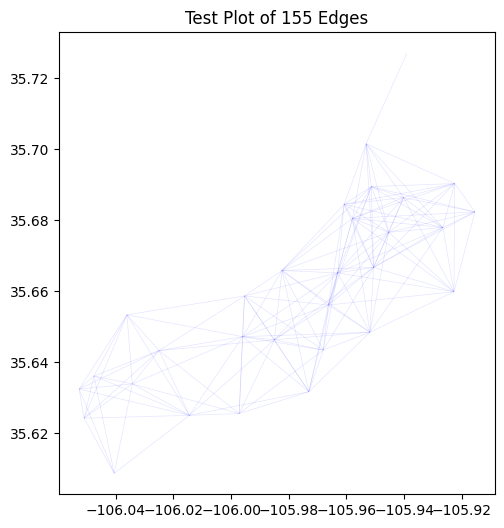

In [11]:
import geopandas as gpd
import matplotlib.pyplot as plt

# Load the saved geojson file
test_geojson_file = data_dir + '/optimal_edges_lines.geojson'
test_gdf = gpd.read_file(test_geojson_file)

print("\nGeoJSON File Verification")

# Check the type (should be a geodateframe)
print(f"Object Type: {type(test_gdf)}")

# Check the geometry type (should be linestring)
print(f"Geometry Type: {test_gdf.geometry.iloc[0].geom_type}")

# Check for successful plotting
fig, ax = plt.subplots(1, 1, figsize=(6, 6))
test_gdf.plot(ax=ax, color='blue', linewidth=0.5, alpha=0.1)
ax.set_title(f"Test Plot of {len(test_gdf)} Edges")
plt.show()
plt.close()

In [12]:
import networkx as nx

# Load the saved GraphML file
test_graphml_file = data_dir + '/optimal_graph.graphml'
test_G = nx.read_graphml(test_graphml_file)

print("\nGraphML File Verification")

# Check node and egde count (should match optimal calculation)
print(f"Nodes Loaded: {test_G.number_of_nodes()}")
print(f"Edges Loaded: {test_G.number_of_edges()}")

# Check edge attribuyes
random_edge = list(test_G.edges(data=True))[0]
print("First Edge Data Check:")
print(f"  Source/Target: {random_edge[0]} / {random_edge[1]}")
print(f"  Attributes: {random_edge[2]}")

# Ensure the required attributes are present
if all(attr in random_edge[2] for attr in ['distance_km', 'time_hours', 'weight']):
    print("Edge attributes (distance, time, weight) are present.")
else:
    print("Edge attributes are missing!")


GraphML File Verification
Nodes Loaded: 30
Edges Loaded: 155
First Edge Data Check:
  Source/Target: 35049001103 / 35049001106
  Attributes: {'distance_km': 2.8666105840160983, 'time_hours': 0.057332211680321966, 'weight': 2.8666105840160983}
Edge attributes (distance, time, weight) are present.


# More Tests

In [13]:
# Count consistency across files
csv_count = len(test_df)
geojson_count = len(test_gdf)
graphml_count = test_G.number_of_edges()

assert csv_count == geojson_count, f"CSV and GeoJSON counts don't match: {csv_count} vs {geojson_count}"
assert csv_count == graphml_count, f"CSV and GraphML counts don't match: {csv_count} vs {graphml_count}"

# Check all edge meta stats make sense
assert (test_df['distance_km'] >= 0).all(), f"Distance is negative"
assert (test_df['time_hours'] >= 0).all(), f"Time is negative"
# assert (test_df['weight'] >= 0).all(), f"Weight is negative"

print("All assertions passed, data is good.")

All assertions passed, data is good.


# Store Metrics

In [14]:
stats_dir_path = os.path.join(data_dir, "stats")
stats_path = os.path.join(stats_dir_path, "stats.json")
stats_data = {}

# Stats dir create
os.makedirs(stats_dir_path, exist_ok=True)

# Stats load
if os.path.exists(stats_path):
    try:
        with open(stats_path, 'r') as f:
            stats_data = json.load(f)
    except Exception as e:
        print("Cant load stats file")

stats_data["optimal_edge_threshold_km"] = optimal_threshold
stats_data["thresholds"] = thresholds

try:
    with open(stats_path, 'w') as f:
        json.dump(stats_data, f, indent=4)
    print("Successful update to stats file")
except Exception as e:
    print("MAJOR: Cant write to stats file")

Successful update to stats file
